# Проект - Отличие сгенерированных изображений от настоящих.

Дисциплина: "Машинное обучение и обработка данных" (ИТМО, 2026)

Выполнили:
- Ракич Тина
- Киселева Анастасия
- Трефилов Яков
- Душкина Надежда
- Давлетов Артём

**Цель проекта:** обучить модель компьютерного зрения для решения задачи отличия сгенерированных изображений от настоящих.


## Описание данных

**Ссылка на датсет:** https://www.kaggle.com/datasets/tristanzhang32/ai-generated-images-vs-real-images

## Загрузка данных

Этот датасет содерижт 30 000 ИИ-сгенерированных изображений и 30 000 настоящих изображений

Сгенерированные:

- 10,000 из Stable Diffusion
- 10,000 из MidJourney
- 10,000 из DALL-E

Real:

- 22,500 из Pexels, Unsplash
- 7,500 из WikiArt


In [1]:
# установка и загрузка библиотек
!pip install kagglehub

In [2]:
!pip install torch torchvision albumentations

In [3]:
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageDraw
import numpy as np
import csv

import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage, ToTensor

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Subset
import random

import kagglehub

Выберите свой путь до датасета:

In [11]:
from google.colab import drive
drive.mount('/content/drive')

path = 'drive/MyDrive/ITMO_ML_project_2/Data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# загрузка датасета с Kaggle
# path = kagglehub.dataset_download("tristanzhang32/ai-generated-images-vs-real-images")

# print("Path to dataset files:", path)

In [24]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import torch
import numpy as np
from torchvision import transforms


class AIGeneratedVsRealDataset(Dataset):
    """
    Dataset:
        root/
          train/
            fake/
            real/
          test/
            fake/
            real/

    Метки:
        fake -> 1
        real -> 0
    """

    def __init__(self, root, split='train', transform=None,
                 img_extensions=('.jpg', '.jpeg', '.png')):
        self.root = Path(root) / split
        if not self.root.exists():
            raise FileNotFoundError(f"Path does not exist: {self.root}")

        self.transform = transform
        self.img_extensions = tuple(e.lower() for e in img_extensions)

        self.class_to_label = {
            'real': 0,
            'fake': 1,
        }

        self.items = []

        for class_name, label in self.class_to_label.items():
            class_dir = self.root / class_name
            if not class_dir.exists():
                raise RuntimeError(f"Missing folder: {class_dir}")

            for img_path in class_dir.rglob('*'):
                if img_path.is_file() and img_path.suffix.lower() in self.img_extensions:
                    self.items.append((img_path.resolve(), label))

        if len(self.items) == 0:
            raise RuntimeError("Dataset is empty. Check folder structure.")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, label = self.items[idx]
        img = Image.open(img_path).convert('RGB')

        if self.transform is not None:
            img = np.array(img)
            img = self.transform(image=img)['image']
        else:
            img = transforms.ToTensor()(img)

        label = torch.tensor(label, dtype=torch.long)
        return img, label

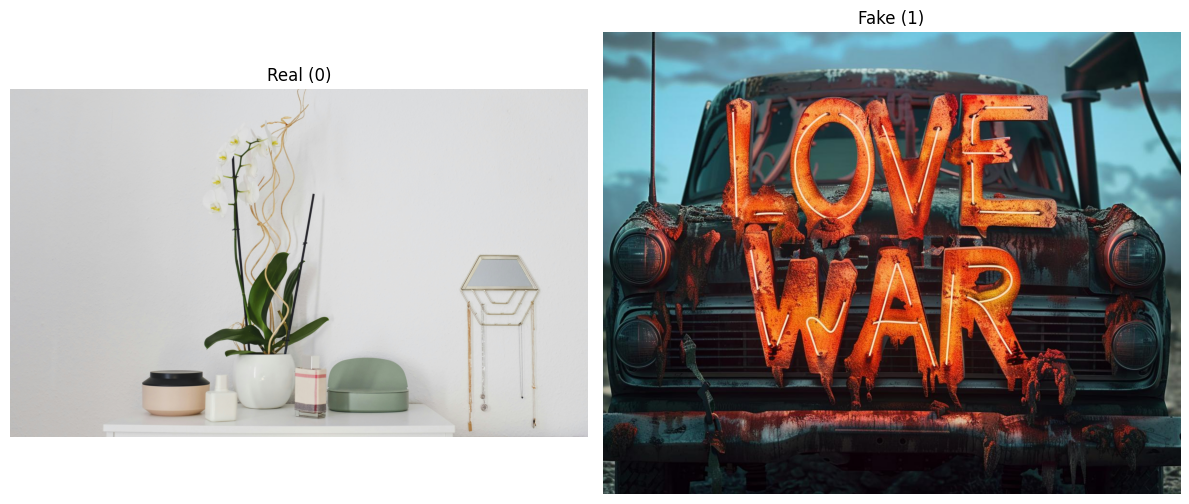

In [27]:
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch
from torchvision.transforms import ToPILImage


def tensor_to_pil_image(img_tensor):
    if isinstance(img_tensor, torch.Tensor):
        img_tensor = img_tensor.detach().cpu()
        if img_tensor.ndim == 3:
            return ToPILImage()(img_tensor)
    raise TypeError("Expected img_tensor to be a 3D torch.Tensor")


def decode_label(label):
    return 'Fake' if label == 1 else 'Real'


def visualize_sample(dataset, idx, ax=None):
    img_tensor, label = dataset[idx]

    if isinstance(label, torch.Tensor):
        label = int(label.item())
    else:
        label = int(label)

    pil_img = tensor_to_pil_image(img_tensor)
    label_name = decode_label(label)

    if ax is not None:
        ax.imshow(pil_img)
        ax.set_title(f'{label_name} ({label})')
        ax.axis('off')
    else:
        plt.figure(figsize=(6, 6))
        plt.imshow(pil_img)
        plt.title(f'{label_name} ({label})')
        plt.axis('off')
        plt.show()

    return pil_img, label_name


def visualize_one_per_class(dataset):
    seen = {}

    for idx in range(len(dataset)):
        _, label = dataset[idx]

        if isinstance(label, torch.Tensor):
            label = int(label.item())
        else:
            label = int(label)

        if label not in seen:
            seen[label] = idx

        if len(seen) == 2:
            break

    if len(seen) == 0:
        raise RuntimeError("Dataset is empty or labels were not found")

    sorted_items = sorted(seen.items(), key=lambda x: x[0])

    fig, axes = plt.subplots(1, len(sorted_items), figsize=(6 * len(sorted_items), 6))

    if len(sorted_items) == 1:
        axes = [axes]

    for ax, (_, idx) in zip(axes, sorted_items):
        visualize_sample(dataset, idx, ax=ax)

    plt.tight_layout()
    plt.show()


dataset_root = Path(path)
dataset = AIGeneratedVsRealDataset(root=dataset_root, split='train')

visualize_one_per_class(dataset)

### Преобразование данных (аугментации)

In [55]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

train_alb = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(-0.03, 0.03),
        rotate=(-10, 10),
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5,
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5,
    ),

    A.HueSaturationValue(
        hue_shift_limit=8,
        sat_shift_limit=12,
        val_shift_limit=8,
        p=0.4,
    ),

    A.GaussNoise(
        std_range=(0.04, 0.12),
        mean_range=(0.0, 0.0),
        p=0.3,
    ),

    A.OneOf([
        A.MotionBlur(blur_limit=3),
        A.MedianBlur(blur_limit=3),
        A.GaussianBlur(blur_limit=3),
    ], p=0.2),

    A.ImageCompression(
        quality_range=(60, 100),
        p=0.3,
    ),

    A.RandomResizedCrop(
        size=(224, 224),
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1),
        p=1.0,
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=255.0,
    ),

    ToTensorV2(),
])

val_alb = A.Compose([
    A.Resize(224, 224),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=255.0,
    ),

    ToTensorV2(),
])

### Разделение набора данных на train и валидацию

In [56]:
import random
from collections import defaultdict
from torch.utils.data import Subset


def stratified_split(dataset, val_ratio=0.2, seed=42):
    label_to_indices = defaultdict(list)

    # собираем индексы по классам
    for idx in range(len(dataset)):
        _, label = dataset[idx]

        if hasattr(label, "item"):
            label = int(label.item())
        else:
            label = int(label)

        label_to_indices[label].append(idx)

    train_idx = []
    val_idx = []

    rnd = random.Random(seed)

    # делим внутри каждого класса
    for _, indices in label_to_indices.items():
        rnd.shuffle(indices)
        split = int(len(indices) * (1 - val_ratio))

        train_idx.extend(indices[:split])
        val_idx.extend(indices[split:])

    # перемешиваем итоговые списки
    rnd.shuffle(train_idx)
    rnd.shuffle(val_idx)

    return train_idx, val_idx


# базовый датасет без аугментаций
base_ds = AIGeneratedVsRealDataset(
    root=dataset_root,
    split='train',
    transform=None
)

# стратифицированное разбиение
train_idx, val_idx = stratified_split(base_ds, val_ratio=0.2, seed=42)

train_base = Subset(base_ds, train_idx)
val_base = Subset(base_ds, val_idx)

print(
    'Sizes — all:', len(base_ds),
    '\ntrain:', len(train_base),
    '\nval:', len(val_base)
)

Sizes — all: 20 
train: 16 
val: 4


In [57]:
train_ds = AIGeneratedVsRealDataset(
    root=dataset_root,
    split='train',
    transform=train_alb
)

val_ds = AIGeneratedVsRealDataset(
    root=dataset_root,
    split='train',
    transform=val_alb
)

train_ds = Subset(train_ds, train_idx)
val_ds = Subset(val_ds, val_idx)

#### Резюме для дальнейшей работы:

- Создан класс `AIGeneratedVsRealDataset` для загрузки изображений и меток классов.
- Для аугментаций определены трансформации `train_alb` и `val_alb`.
- Функции `visualize_sample(dataset, idx)` и `visualize_one_per_class(dataset)` позволяют отображать отдельные изображения и по одному примеру каждого класса с соответствующей меткой.

## Подготовка данных для ResNet-50

В дальнейшей части проекта мы планируем использовать сверточную
нейронную сеть ResNet-50 для задачи бинарной классификации
изображений: определение, является ли изображение
сгенерированным (AI-generated) или реальным (Real).

Данная модель ожидает, что датасет будет возвращать для
каждого изображения:

img: Tensor[C, H, W]
label: int (0 или 1)

где:
- 0 — Real (реальное изображение)
- 1 — AI (сгенерированное изображение)

В отличие от задачи детекции объектов (например, Faster R-CNN),
здесь не требуется информация о bounding boxes и координатах
объектов. Модель решает задачу классификации всего изображения
целиком.

Наш класс AIGeneratedVsRealDataset возвращает данные в виде:

img: Tensor[C, H, W]
target: словарь
{
    "label": Tensor[1],
    "image_id": ...,
    "file_path": ...
}

Для обучения ResNet-50 достаточно использовать только метку
класса (label), поэтому при формировании батчей можно
упростить выход датасета до пары:

(img, label)

где label ∈ {0, 1}.

Таким образом, дополнительная адаптация датасета, аналогичная
случаю Faster R-CNN, не требуется. Основная подготовка данных
сводится к применению аугментаций и приведению изображений
к единому размеру.

Использование классификационной модели вместо детектора
объектов обусловлено тем, что в данной задаче важны
глобальные и текстурные особенности изображения
(например, артефакты генерации), а не локализация
конкретных объектов.


In [58]:
from torch.utils.data import DataLoader, Subset

# датасет для разбиения без аугментаций
base_ds = AIGeneratedVsRealDataset(
    root=dataset_root,
    split='train',
    transform=None
)

# индексы train / val
train_idx, val_idx = stratified_split(base_ds, val_ratio=0.2, seed=42)

# отдельные датасеты с нужными аугментациями
train_ds_full = AIGeneratedVsRealDataset(
    root=dataset_root,
    split='train',
    transform=train_alb
)

val_ds_full = AIGeneratedVsRealDataset(
    root=dataset_root,
    split='train',
    transform=val_alb
)

# подмножества
train_ds = Subset(train_ds_full, train_idx)
val_ds = Subset(val_ds_full, val_idx)

# обычные DataLoader'ы для классификации
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train size:", len(train_ds))
print("Val size:  ", len(val_ds))

Train size: 16
Val size:   4


In [59]:
# Проверка для одного батча
images_batch, labels_batch = next(iter(train_loader))

print("Batch tensor shape:", images_batch.shape)   # [B, C, H, W]
print("Labels tensor shape:", labels_batch.shape)  # [B]
print("Batch labels:", labels_batch)

Batch tensor shape: torch.Size([16, 3, 224, 224])
Labels tensor shape: torch.Size([16])
Batch labels: tensor([1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1])


## Создание ResNet-50 и обучение модели

In [60]:
# загрузка дополнительных библиотек
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# загружаем ResNet-50 с предобученными весами
model = resnet50(weights=ResNet50_Weights.DEFAULT)

# заменяем последний классификационный слой под 2 класса: real / fake
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 2)

model = model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [61]:
# Проверка на 1 батче

images_batch, labels_batch = next(iter(train_loader))

images_batch = images_batch.to(device)
labels_batch = labels_batch.to(device)

model.train()

logits = model(images_batch)
criterion = nn.CrossEntropyLoss()
loss = criterion(logits, labels_batch)

print("Images batch shape:", images_batch.shape)
print("Labels batch shape:", labels_batch.shape)
print("Logits shape:", logits.shape)
print("Loss:", float(loss))

Images batch shape: torch.Size([16, 3, 224, 224])
Labels batch shape: torch.Size([16])
Logits shape: torch.Size([16, 2])
Loss: 0.7168183326721191


/tmp/ipykernel_9023/1172507719.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("Loss:", float(loss))


### Обучение модели

In [62]:
from tqdm import tqdm
import copy
import torch


def compute_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total

In [63]:
from tqdm import tqdm
import copy
import torch


def compute_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total


def train_classification_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    lr_scheduler,
    criterion,
    device,
    num_epochs=20,
    save_path="best_model.pth"
):
    """
    Обучение модели классификации:
      - Train loss
      - Train accuracy
      - Val loss
      - Val accuracy

    Сохраняет лучшую модель по accuracy на валидации.
    """
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    model.to(device)

    for epoch in range(num_epochs):
        # =========================
        # Обучение
        # =========================
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]", unit="batch")

        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(logits, dim=1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

            batch_acc = (preds == labels).float().mean().item()
            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{batch_acc:.4f}"
            })

        epoch_train_loss = running_loss / running_total
        epoch_train_acc = running_correct / running_total

        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)

        # =========================
        # Валидация
        # =========================
        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]", unit="batch")

            for images, labels in pbar_val:
                images = images.to(device)
                labels = labels.to(device)

                logits = model(images)
                loss = criterion(logits, labels)

                val_loss_sum += loss.item() * images.size(0)

                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                batch_acc = (preds == labels).float().mean().item()
                pbar_val.set_postfix({
                    "loss": f"{loss.item():.4f}",
                    "acc": f"{batch_acc:.4f}"
                })

        epoch_val_loss = val_loss_sum / val_total
        epoch_val_acc = val_correct / val_total

        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        print(
            f"\nEpoch {epoch+1}/{num_epochs} — "
            f"Train Loss: {epoch_train_loss:.4f}, "
            f"Train Acc: {epoch_train_acc:.4f}, "
            f"Val Loss: {epoch_val_loss:.4f}, "
            f"Val Acc: {epoch_val_acc:.4f}"
        )

        if lr_scheduler is not None:
            lr_scheduler.step()

        # Сохранение лучшей модели
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, save_path)
            print(f"Saved new best model (Val Acc improved to {epoch_val_acc:.4f})")

    print("Training complete!")
    return history, best_model_wts

In [67]:
import math
import torch


class FixedBatchDataset(torch.utils.data.Dataset):
    def __init__(self, batches):
        self.batches = batches

    def __len__(self):
        return len(self.batches)

    def __getitem__(self, idx):
        return self.batches[idx]


def identity_collate(batch):
    return batch[0]


def take_n_batches(loader, n):
    batches = []
    it = iter(loader)

    for _ in range(n):
        try:
            batches.append(next(it))
        except StopIteration:
            break

    return batches


train_batches = take_n_batches(train_loader, 5)
val_batches = take_n_batches(val_loader, 5)

two_batch_loader = torch.utils.data.DataLoader(
    FixedBatchDataset(train_batches),
    batch_size=1,
    shuffle=False,
    collate_fn=identity_collate
)

val_two_batch_loader = torch.utils.data.DataLoader(
    FixedBatchDataset(val_batches),
    batch_size=1,
    shuffle=False,
    collate_fn=identity_collate
)

print("Train debug batches:", len(train_batches))
print("Val debug batches:", len(val_batches))

Train debug batches: 1
Val debug batches: 1


In [68]:
import torch
import torch.nn as nn

# функция потерь
criterion = nn.CrossEntropyLoss()

# оптимизатор
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    params,
    lr=1e-4,
    weight_decay=1e-4
)

# scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

# обучение
history, best_weights = train_classification_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    criterion=criterion,
    device=device,
    num_epochs=15,
    save_path="resnet50_15epochs_adamw_lr1e-4_with_augmentations.pth"
)

# загрузка лучших весов
model.load_state_dict(best_weights)

Epoch 1/15 [Validation]: 100%|██████████| 1/1 [00:02<00:00,  2.13s/batch, loss=0.6562, acc=0.7500]



Epoch 1/15 — Train Loss: 0.6794, Train Acc: 0.5625, Val Loss: 0.6562, Val Acc: 0.7500
Saved new best model (Val Acc improved to 0.7500)


Epoch 2/15 [Validation]: 100%|██████████| 1/1 [00:02<00:00,  2.17s/batch, loss=0.6375, acc=0.7500]



Epoch 2/15 — Train Loss: 0.6169, Train Acc: 0.6875, Val Loss: 0.6375, Val Acc: 0.7500


Epoch 3/15 [Validation]: 100%|██████████| 1/1 [00:02<00:00,  2.20s/batch, loss=0.6179, acc=0.5000]


...

Epoch 14/15 [Validation]: 100%|██████████| 1/1 [00:02<00:00,  2.60s/batch, loss=0.6250, acc=0.7500]



Epoch 14/15 — Train Loss: 0.4459, Train Acc: 1.0000, Val Loss: 0.6250, Val Acc: 0.7500


Epoch 15/15 [Validation]: 100%|██████████| 1/1 [00:02<00:00,  2.24s/batch, loss=0.6262, acc=0.7500]


Epoch 15/15 — Train Loss: 0.4421, Train Acc: 1.0000, Val Loss: 0.6262, Val Acc: 0.7500
Training complete!


<All keys matched successfully>

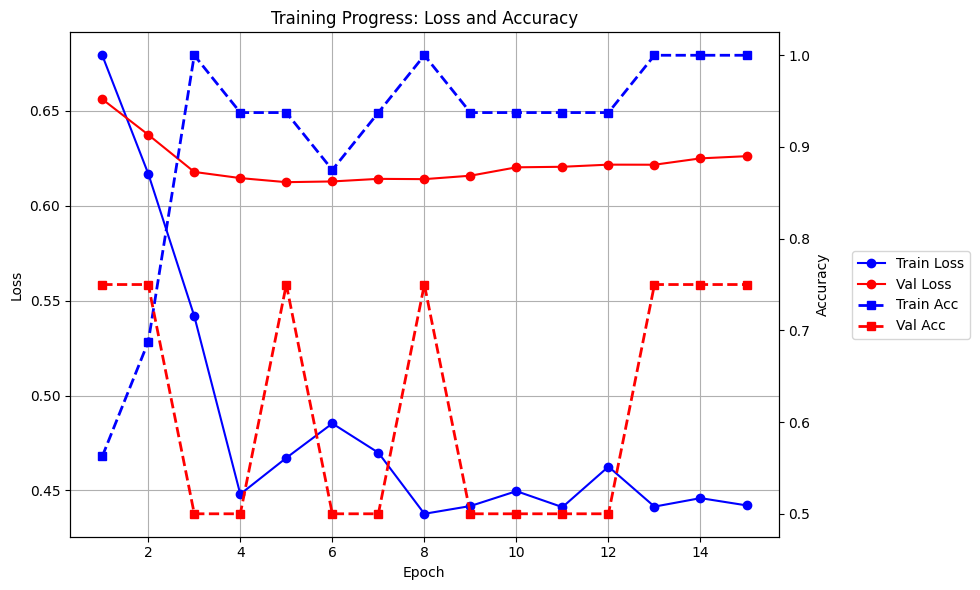

In [71]:
import matplotlib.pyplot as plt


def plot_classification_history(history):
    """
    Визуализация:
      - train/val loss
      - train/val accuracy

    history: dict с ключами:
        'train_loss', 'val_loss', 'train_acc', 'val_acc'
    """
    epochs = range(1, len(history['train_loss']) + 1)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Loss
    l1, = ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    l2, = ax1.plot(epochs, history['val_loss'], 'r-o', label='Val Loss')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True)

    # Accuracy
    ax2 = ax1.twinx()
    l3, = ax2.plot(epochs, history['train_acc'], 'b--s', label='Train Acc', linewidth=2)
    l4, = ax2.plot(epochs, history['val_acc'], 'r--s', label='Val Acc', linewidth=2)
    ax2.set_ylabel("Accuracy")

    # Легенда
    lines = [l1, l2, l3, l4]
    labels = [line.get_label() for line in lines]
    fig.legend(lines, labels, loc='center left', bbox_to_anchor=(0.85, 0.5))

    plt.title("Training Progress: Loss and Accuracy")
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

plot_classification_history(history)

In [72]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms


def classify_and_visualize(model, image, device, class_names=None):
    """
    Запускает модель классификации и визуализирует результат.

    Аргументы:
        model: обученная модель классификации.
        image: PIL Image.
        device: torch.device.
        class_names: dict, например {0: 'Real', 1: 'Fake'}

    Возвращает:
        pred_class: предсказанный класс
        pred_prob: вероятность предсказанного класса
    """
    if class_names is None:
        class_names = {0: 'Real', 1: 'Fake'}

    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        )
    ])

    img_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_prob = probs[0, pred_idx].item()

    pred_class = class_names[pred_idx]

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f'Prediction: {pred_class} | Confidence: {pred_prob:.4f}')
    plt.axis('off')
    plt.show()

    return pred_class, pred_prob

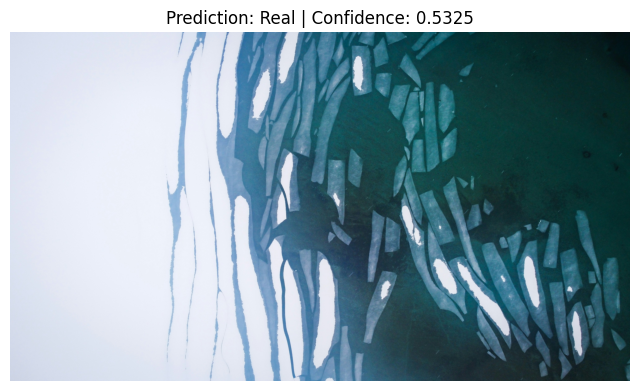

Predicted class: Real
Confidence: 0.5325


In [75]:
from PIL import Image

image = Image.open(path+"/test/real/0001.jpg").convert("RGB")
pred_class, pred_prob = classify_and_visualize(model, image, device)

print(f"Predicted class: {pred_class}")
print(f"Confidence: {pred_prob:.4f}")

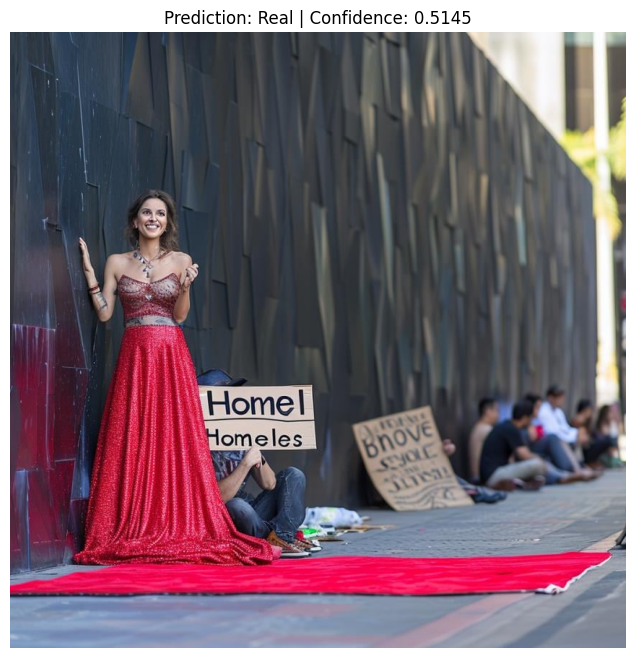

Predicted class: Real
Confidence: 0.5145


In [76]:
image = Image.open(path+"/test/fake/0001.jpg").convert("RGB")
pred_class, pred_prob = classify_and_visualize(model, image, device)

print(f"Predicted class: {pred_class}")
print(f"Confidence: {pred_prob:.4f}")

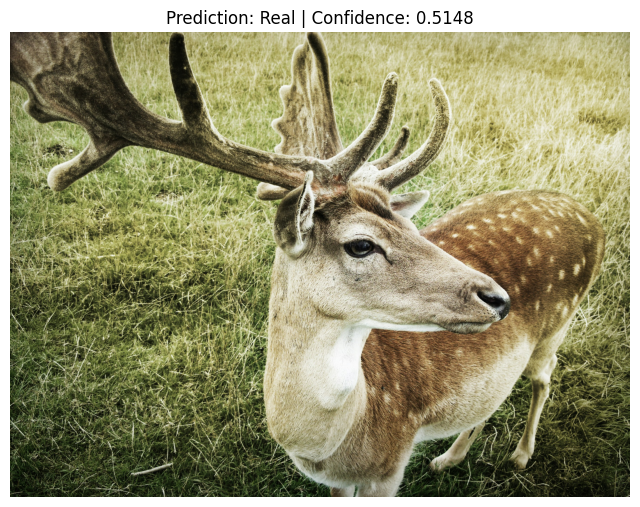

Predicted class: Real
Confidence: 0.5148


In [77]:
image = Image.open(path+"/test/real/0002.jpg").convert("RGB")
pred_class, pred_prob = classify_and_visualize(model, image, device)

print(f"Predicted class: {pred_class}")
print(f"Confidence: {pred_prob:.4f}")

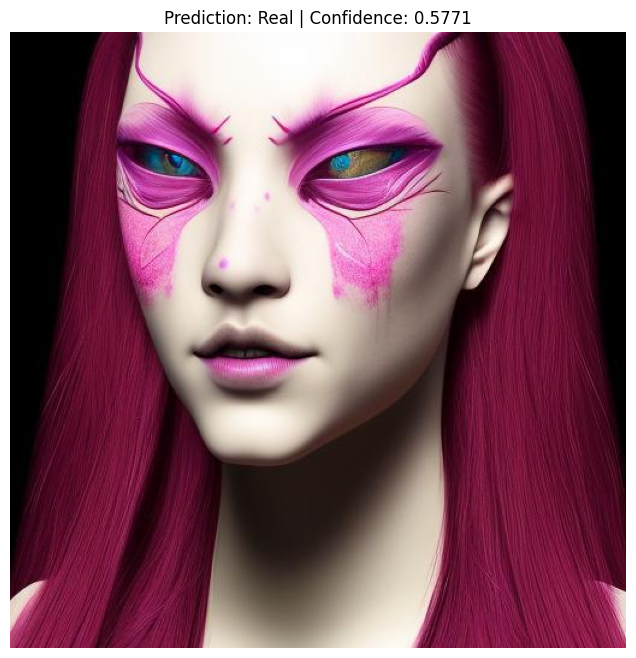

Predicted class: Real
Confidence: 0.5771


In [78]:
image = Image.open(path+"/test/fake/0002.jpg").convert("RGB")
pred_class, pred_prob = classify_and_visualize(model, image, device)

print(f"Predicted class: {pred_class}")
print(f"Confidence: {pred_prob:.4f}")

In [79]:
# Сохранение полученных итоговых метрики
for k, v in zip(history.keys(), history.values()):
  print(f'{k} : {v[len(v)-1]:.4f}')

train_loss : 0.4421
train_acc : 1.0000
val_loss : 0.6262
val_acc : 0.7500
